In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
import scipy.signal
from scipy.signal import spectrogram
from matplotlib.patches import Patch
from TIF import Info, Anotaciones

In [3]:
class RawSignal:
    """
    Clase para manejar señales fisiológicas en formato NumPy.
    Este constructor permite inicializar el objeto 'RawSignal' a partir de un array de datos ,
    con información adicional de los canales y el índice de la primera muestra."""
    
    def __init__(self, data:np.ndarray, sfreq:float, info:Info=None, anotaciones:Anotaciones=None, first_samp:int=0):
        """
        Inicializa una instancia de la clase RawSignal.
        
        Args:
            data : Array de datos con forma '(n_canales , n_muestras)'.
            sfreq : Frecuencia de muestreo de la señal en Hz.
            info : Por defecto es None. Información adicional sobre la señal. El diccionario contiene info relevante de la señal
            anotaciones : Objeto de tipo Anotaciones que almacena eventos asociados a la señal y al experimento.
            first_samp : Indica el tiempo de inicio del segmento, pero no recorta los datos. (Por defecto es 0)
            
        Raises:
            ValueError : Si el array 'data' no tiene la forma '(n_canales , n_muestras)'.
            ValueError : Si el índice 'first_samp' está fuera del rango de la señal. """
        
        if not isinstance(data, np.ndarray):     # Que data sea un array de NumPy
            raise ValueError("El parámetro 'data' debe ser un array de NumPy (np.ndarray).")

        if data.ndim != 2:                       # Que data tenga dos dimensiones 
            raise ValueError("El array 'data' debe tener dos dimensiones: (n_canales, n_muestras).")

        n_muestras = data.shape[1]               # Número de muestras es la segunda dimensión
        if not (0 <= first_samp < n_muestras):   # Que first_samp sea un entero positivo y menor que el numero de muestras
            raise ValueError("El índice 'first_samp' está fuera del rango de muestras disponibles.")


        if info is not None and info["Nombre canales"] is not None:
            if len(info["Nombre canales"]) != data.shape[0]:
                raise ValueError(f"La cantidad de canales de la señal ({data.shape[0]}) no coincide con la cantidad ingresada en el objeto Info ({len(info['Nombre canales'])})")
        
        self.data = data
        self.sfreq = sfreq
        self.info = info
        self.first_samp = first_samp

        if anotaciones is not None:
            self.validar_anotaciones(anotaciones)    # Validación estructurada
            self.anotaciones = anotaciones
    
    def validar_anotaciones(self, anotaciones:Anotaciones):
        """
        Verifica que las anotaciones estén dentro del rango temporal de la señal.

        Args:
            anotaciones :  Objeto de la clase 'Anotaciones' que contiene la información de los eventos.

        Raises:
            TypeError : Si el parámetro 'anotaciones' no es una instancia de la clase 'Anotaciones'.
            ValueError : Si alguna anotación está fuera del rango temporal de la señal. """

        if not isinstance(anotaciones, Anotaciones):
            raise TypeError("El parámetro 'anotaciones' debe ser una instancia de la clase 'Anotaciones'.")

        df = anotaciones.get_annotations()                # Método de la clase Anotaciones

        duracion_total = (self.data.shape[1] / self.sfreq) + self.first_samp  # Duración total de la señal

        for i, fila in df.iterrows():                     # Validar que todas las anotaciones estén dentro del rango
            inicio = fila["Inicio"]
            duracion = fila["Duracion"]
            if not (0 <= inicio <= duracion_total):
                raise ValueError(f"Anotación con inicio en {inicio}s fuera del rango (0 - {duracion_total:.2f}s).")
            if inicio + duracion > duracion_total:
                raise ValueError(f"Anotación desde {inicio}s con duración {duracion}s excede el final de la señal.")

        self.anotaciones = anotaciones
    
    def set_anotaciones(self, anotaciones: Anotaciones):
        """
        Asocia o reemplaza el objeto 'Anotaciones' de la señal, validando que esté en rango.

        Args:
            anotaciones : Objeto de la clase 'Anotaciones' que contiene la información de los eventos.

        Raises:
            TypeError : Si el parámetro no es de tipo 'Anotaciones'.
            ValueError : Si alguna anotación está fuera del rango temporal de la señal.
        """
        self.validar_anotaciones(anotaciones)
        self.anotaciones = anotaciones
        
    def get_data(self, picks=None, start:float|int=0, stop:float|int=0, reject:float=None, times:bool=False):
        """
        Obtiene muestras de la señal en un rango dado.
        Args:
            picks (str o array_like) : Canales o índices a extraer. Si es 'None', se seleccionan todos los canales.
            start : Tiempo inicial (en segundos) para extraer muestras (por defecto 0).
            stop : Tiempo final (en segundos) para extraer muestras (por defecto 0, que significa hasta el final de la señal).
            reject : Valor pico a pico de umbral para rechazar canales. Si una muestra supera este umbral, el canal se descarta (por defecto 'None').
            times : Si es 'True', se retorna también el vector de tiempos asociado a las muestras.

        Returns:
            np.ndarray : Matriz con los datos seleccionados (n_canales x n_muestras).
            np.ndarray (opcional) : Vector de tiempos (solo si 'times=True').

        Raises
            ValueError : Si los índices seleccionados están fuera de rango. """
        
        n_canales, n_muestras = self.data.shape                       # Número de canales y muestras  
    
        start_idx = int(start * self.sfreq)                           # Convertir start de segundos a número de muestra
        stop_idx = int(stop * self.sfreq) if stop > 0 else n_muestras # Si stop es mayor que 0, convertir a indice de muestra, sino, tomar hasta el final

        if not (0 <= start_idx < stop_idx <= n_muestras):             # Si no se cumple que start_idx es mayor o igual a 0 y menor que stop_idx y ademas stop_idx es menor o igual al numero de muestras, lleva al error
            raise ValueError("Índices de tiempo fuera de rango.")

        # Seleccionar canales
        if picks is None:                             # Si picks queda por defecto, seleccionar todos los canales
            canales_idx = np.arange(n_canales)

        elif isinstance(picks, (list, np.ndarray)):
            if all(isinstance(pick, int) for pick in picks):   # Verificar que los canales ingresados sean todos enteros
                if np.isin(picks, np.arange(n_canales)).all(): # Verificar si los canales ingresados existen
                    canales_idx = np.array(picks)
                else:
                    raise ValueError("Error: algunos canales ingresados no existen")
            
            elif all(isinstance(pick, str) for pick in picks):   # Verificar que los canales ingresados sean todos strings
                if self.info is None:
                    raise ValueError("Debe ingresar el objeto Info")
                
                nombres = self.info.get("Nombre canales")       # Aplicamos el médoto de Info para obtener los canales del diccionario
                try:
                    canales_idx = [nombres.index(canal) for canal in picks] # Si "canal" esta en los canels pasados desde Info, obtiene el indice y se agrega a canales_idx
                except ValueError:
                    raise ValueError(f"Error: uno o más canales no se encuentran en los canales Ingresados desde el objeto Info")
            else:
                raise ValueError("Error: los canales ingresados no tienen el mismo formato")

        else:
            raise ValueError("Formato de 'picks' inválido. Deben ser strings o enteros.")

        datos = self.data[np.array(canales_idx), start_idx : stop_idx]  # Extraer datos de los canales

        if reject is not None:                 # Aplicar umbral de rechazo si se especifica
            pico_pico = np.ptp(datos, axis=1)  # Toma el max y min del canal y los resta, obteniendo el valor pico_pico de cada canal (axis=1 filas)
            filtro = pico_pico < reject        # Filtro para quedarme solo con los valores pico_pico menores a reject
            datos = datos[filtro]

        if times is True:
            tiempo_vector = (np.arange(start_idx, stop_idx) / self.sfreq) + self.first_samp
            
            return datos, tiempo_vector

        return datos
        
    def crop(self, tmin:int|float=0.0, tmax:int|float=None) -> "RawSignal":
        """
        Obtiene un trozo de RawSignal. Limita los datos dentro de RawSignal
        para obtener un nuevo objeto RawSignal pero con una cantidad de muestras recortadas.
        
        Args:
            tmin : Tiempo inicial en segundos para iniciar el recorte (por defecto es 0.0).
            tmax : Tiempo final en segundos para finalizar el recorte (por defecto es None).
        
        Returns:
            RawSignal : Nueva instancia de 'RawSignal' que contiene el segmento temporal recortado.
        
        Raises
            Value Error : Si los tiempos 'tmin' o 'tmax' están fuera del rango de la señal. """
        
        n_canales, n_muestras = self.data.shape
        duracion_total = n_muestras / self.sfreq

        anotaciones_copia = copy.deepcopy(self.anotaciones)
        anotaciones_copia.recorte(tmin=tmin, tmax=tmax)               # Elimina las anotaciones que superan el tmax del recorte

        # Validaciones
        if not isinstance(tmin, (int, float)) or tmin < 0:             # Si tmin no es entero, flotante o positivo
            raise ValueError("'tmin' debe ser un número positivo.")
        
        if tmax is not None:
            if not isinstance(tmax, (int, float)) or tmax <= tmin:     # Si tmax no es un número o es menor a tmin
                raise ValueError("'tmax' debe ser mayor que 'tmin'.")
            elif tmax > duracion_total:                                # Si tmax es mayor que la duracion total de la señal
                raise ValueError(f"'tmax' está fuera del rango de la señal ({duracion_total:.2f} s).")

        if tmin > duracion_total:                                      #Chequeo si tmin es mayor que la duracion total de la señal 
            raise ValueError(f"'tmin' está fuera del rango de la señal ({duracion_total:.2f} s).")

        start_idx = int(tmin * self.sfreq)                             # Convertir a índices
        end_idx = int(tmax * self.sfreq) if tmax is not None else n_muestras

        datos_crop = self.data[:, start_idx:end_idx]                   # De todos los canales (:), extraer el segmento de la señal (start_idx:end_idx)

        return RawSignal(data=datos_crop, sfreq=self.sfreq, info=self.info, anotaciones=anotaciones_copia, first_samp= self.first_samp + tmin) # El segmento recortado empieza en 0 (first_samp)
    
    def drop_channels(self, ch_names:list|np.ndarray) -> "RawSignal":
        """ 
        Elimina uno o más canales a partir de ch_names.

        Args:
            ch_names : Nombres de canales a eliminar

        Returns:
            Objeto RawSignal """

        # Validaciones
        if self.info is None or self.info.get("Nombre canales") is None:
            raise ValueError("No se puede eliminar canales sin el objeto Info con los nombres de los canales")
        
        canales_actuales = self.info["Nombre canales"]
        datos_actuales = self.data
        info_copia = copy.deepcopy(self.info)

        if all(isinstance(ch, str) for ch in ch_names):    # Si todos los canales son str
            try:
                indices_eliminar = [canales_actuales.index(nombre) for nombre in ch_names]
            except ValueError as e:
                raise ValueError(f"Uno o más nombres de canal no se encuentran en la lista: {e}")
            
        elif all(isinstance(ch, int) for ch in ch_names):  # Si todos los canales son int
            indices_eliminar = ch_names
        
        else:
            raise ValueError("Todos los elementos de 'ch_names' deben ser del mismo tipo (str o int).")
        
        datos_filtrados = np.delete(datos_actuales, indices_eliminar, axis=0)   # Elimina los indices (canales) de la señal

        info_copia.eliminar_elementos(key="Nombre canales", elementos=ch_names)

        return RawSignal(data=datos_filtrados, sfreq=self.sfreq, info=info_copia, anotaciones=self.anotaciones, first_samp=self.first_samp)

    def describe(self, archivo_salida):
        """
        Genera un DataFrame con estadísticas descriptivas para cada canal de la señal.

        Para cada canal se obtiene:
        - Nombre: Nombre del canal.
        - Tipo: Tipo de canal (eeg, ecg, emg).
        - Min: Valor mínimo del canal.
        - Q1: Primer cuartil (percentil 25%).
        - Mediana: Mediana (percentil 50%).
        - Q3: Tercer cuartil (percentil 75%).
        - Max: Valor máximo del canal.

        Args:
            archivo_salida : Nombre del archivo csv que se genera

        Returns:
            pd.DataFrame : Tabla con una fila por estadístico y una columna por canal. """
        
        n_canales = 0

        if self.info is not None:
            if "Nombre canales" in self.info:
                nombres = self.info.get("Nombre canales")
                n_canales = len(nombres)

            if "Tipo canales" in self.info:
                tipos = self.info.get("Tipo canales")
        
        if self.info is None: 
            n_canales = self.data.shape[0]
            nombres = [f"Canal_{i+1}" for i in range(n_canales)]
            tipos = ["Desconocido"] * n_canales
        
        tabla = {}

        for i in nombres:
            indice = nombres.index(i)
            canal = self.data[indice]
            resumen = {
                "Nombre canal": i,
                "Tipo canal": tipos[indice],
                "Min": np.min(canal),
                "Q1": np.percentile(canal, 25),
                "Mediana": np.median(canal),
                "Q3": np.percentile(canal, 75),
                "Max": np.max(canal) }
            tabla[i] = resumen

        datos = pd.DataFrame(tabla)
        datos.to_csv(archivo_salida, index=False)

        return datos

    def filter(self, l_freq:float, h_freq:float, notch_freq:float = 50.0, order:int = 4) -> "RawSignal":
        """
        Aplica un filtro pasabanda (Butterworth) y un filtro notch a la señal fisiológica.
        El filtro notch permite eliminar una frecuencia fija (por defecto 50 Hz).
        Filtro pasabanda Butterworth que permite mantener solo las frecuencias entre l_freq y h_freq.

        Args:
            l_freq : Frecuencia de corte baja del filtro pasabanda (en Hz).
            h_freq : Frecuencia de corte alta del filtro pasabanda (en Hz).
            notch_freq : Frecuencia del filtro notch para eliminar ruido (por defecto 50 Hz).
            order : Orden del filtro Butterworth (por defecto 4).

        Returns:
            RawSignal : Nueva instancia de RawSignal con los datos filtrados.

        Raises:
            ValueError : Si las frecuencias de corte no son válidas. """
        
        if l_freq >= h_freq:
            raise ValueError("La frecuencia de corte mínima debe ser menor que la de corte máxima.")
        
        if notch_freq <= 0 or l_freq <= 0 or h_freq <= 0:
            raise ValueError("Las frecuencias deben ser mayores que cero.")

        datos_filtrados = np.empty_like(self.data)   # Crear un nuevo array para almacenar los datos filtrados. empty_like: Return a new array with the same shape and type as a given array.

        # Diseño del filtro notch
        Q = 30.0  # Factor de calidad del notch (más alto = más estrecho)
        b_notch, a_notch = scipy.signal.iirnotch(notch_freq, Q, self.sfreq)

        # Diseño del filtro pasabanda Butterworth
        b_band, a_band = scipy.signal.butter(order, [l_freq, h_freq], btype='band', fs=self.sfreq)

        for i in range(self.data.shape[0]):                                           # Aplica los filtros a cada canal de la señal
            canal = self.data[i]                                                      # Extraer un canal
            canal_filtrado = scipy.signal.filtfilt(b_notch, a_notch, canal)           # Aplica notch
            canal_filtrado = scipy.signal.filtfilt(b_band, a_band, canal_filtrado)    # Aplica pasabanda
            datos_filtrados[i] = canal_filtrado                                       # Guarda resultado

        # return RawSignal(data=datos_filtrados, sfreq=self.sfreq, info=self.info, anotaciones=self.anotaciones, first_samp=self.first_samp)
        return RawSignal(data=datos_filtrados, sfreq=self.sfreq, info=self.info, anotaciones=self.anotaciones, first_samp=self.first_samp)

    def pick(self, canales=None, slice:list=None) -> "RawSignal":
        """
        Retorna un subset de canales seleccionados.

        Args:
            canales : Lista con los canales para armar el subset. Por defecto es None.
                Puede ser:
                    - list[str] : lista de nombres de canales
                    - list[int] : lista de índices de canales
            
            slice : Lista con los extremos para hacer slicing. Por defecto es None.
            
        Returns:
            RawSignal : Nueva instancia con los canales seleccionados.

        Raises: ValueError:
                    Si el canal especificado no existe.
                    Si el índice está fuera del rango de canales. """
        

        if canales is not None and slice is None:
            indices = canales

        elif canales is None and slice is not None:
            indices = list(range(slice[0], slice[1]))

        else:
            raise ValueError ("Error: debe ingresar canales o slice. No se permiten los dos al mismo tiempo")
        
        if self.info is not None:
            subset = self.get_data(picks=indices)
            info_copia = copy.deepcopy(self.info)
            canales_originales = info_copia.get("Nombre canales")           

            canales_eliminar = []
            for canal in canales_originales:
                if canal not in indices:
                    canales_eliminar.append(canal)
            info_copia.eliminar_elementos(key="Nombre canales", elementos= canales_eliminar)
        
        else:
            subset = self.get_data(picks=indices)
            info_copia = None

        return RawSignal(data=subset, sfreq=self.sfreq, info=info_copia, anotaciones=self.anotaciones, first_samp=self.first_samp)    

    def plot(self, picks=None, start:float=0, duration:float=None, show_anotaciones:bool=True):

        """
        Grafica un segmento de la señal fisiológica.

        Args:
            Canal o canales a visualizar. Puede ser:
                - list[str]: lista de nombres de canales,
                - list[int]: lista de índices de canales.
                - Si es None, se grafican todos los canales.

            start : Tiempo inicial (en segundos) desde donde comenzar la visualización (por defecto 0.0).
            duration : Duración del segmento de señal a mostrar en segundos, por defecto None, gráfica toda la señal).

            show_anotaciones (por defecto True): 
                    True : Se muestran las anotaciones sobre la señal.
                    False : No se muestran las anotaciones.
        """  
        
        if duration is None:
            n_muestras = self.data.shape[1]
            duration = n_muestras / self.sfreq

        intervalo_inicio = start
        intervalo_fin = start + duration

        canales, tiempo = self.get_data(picks=picks, start=intervalo_inicio, stop=intervalo_fin, times=True)
        n_canales = canales.shape[0]

        fig, axes = plt.subplots(n_canales, 1, figsize=(10, 3 * n_canales), sharex=True)
        if n_canales == 1:
            axes = [axes]

        for i in range(n_canales):
            axes[i].plot(tiempo, canales[i])
            # Obtener el nombre real del canal si hay Info y picks
            if self.info is not None and "Nombre canales" in self.info:
                if picks is None:
                    nombre = self.info["Nombre canales"][i]
                else:
                    # Obtener los índices reales de los canales seleccionados
                    if all(isinstance(pick, int) for pick in picks):
                        idx = picks[i]
                        nombre = self.info["Nombre canales"][idx]
                    elif all(isinstance(p, str) for p in picks):
                        nombre = picks[i]
                    else:
                        nombre = f"Canal {i}"
                axes[i].set_ylabel("Amplitud (uV)")
                axes[i].set_title(f"Canal: {nombre}")
            else:
                axes[i].set_ylabel("Amplitud (uV)")
                axes[i].set_title(f"Canal {i}")
            axes[i].set_xlabel("Tiempo [s]")
            axes[i].grid(True)

        # El eje x debe mostrar los tiempos absolutos (+ first_samp)
        x_min = self.first_samp + intervalo_inicio
        x_max = self.first_samp + intervalo_fin

        if show_anotaciones and self.anotaciones is not None:
            df = self.anotaciones.get_annotations()
            eventos = df["Descripcion"].unique()
            colormap = plt.colormaps.get_cmap('Set1')  # 'rainbow', 'Set3', cool, plasma

            # Asignar un color único a cada tipo de evento
            colores_eventos = {evento: colormap(i / len(eventos)) for i, evento in enumerate(eventos)}

            for evento, color in colores_eventos.items():
                df_filtrado = df[df["Descripcion"] == evento]

                for _, fila in df_filtrado.iterrows():
                    inicio = fila["Inicio"]
                    duracion = fila["Duracion"]
                    fin = inicio + duracion
                    if (inicio < x_max) and (fin > x_min):
                        sombra_inicio = max(inicio, x_min)
                        sombra_fin = min(fin, x_max)
                        for ax in axes:
                            ax.axvspan(sombra_inicio, sombra_fin, color=color, alpha=0.3)

            handles = [Patch(color=color, label=evento) for evento, color in colores_eventos.items()]
            fig.legend(handles=handles, loc='upper right')
            
        plt.xlim(x_min, x_max)
        plt.tight_layout()
        plt.show()
    
    def __getitem__(self, item:str|list|tuple):
        """
        Permite acceder a subconjuntos de la señal utilizando indexación personalizada.

        El método soporta múltiples formas de indexación:
        
        - Si se pasa un string (str), devuelve todos los datos del canal correspondiente a ese nombre.
        - Si se pasa una lista de strings (list[str]), devuelve los datos de los canales correspondientes.
        - Si se pasa un slice, devuelve todas las muestras del intervalo especificado para todos los canales.
        - Si se pasa una tupla ([list[str], slice]), devuelve las muestras indicadas por el slice para los canales especificados por nombre.

        Args:
            item (str | list[str] | slice | tuple): 
                Clave de acceso para extraer subconjuntos de la señal.
                - str: nombre del canal.
                - list[str]: lista de nombres de canales.
                - slice: intervalo de muestras para todos los canales.
                - tuple: combinación (canales, slice).

        Returns:
            np.ndarray: Submatriz de datos (n_canales x n_muestras) correspondiente a la selección realizada.
        """

        if self.info is None:
            raise ValueError("No se ha proporcionado el objeto Info.")
        
        nombre_canales = self.info.get("Nombre canales")   # Canales que se pasan desde el objeto Info

        if isinstance(item, str):
            canales_idx = nombre_canales.index(item)             
            return self.data[canales_idx,:]

        elif isinstance(item, list):
            canales_idx = [nombre_canales.index(canal) for canal in item]
            return self.data[canales_idx,:]            

        elif isinstance(item, slice):
            return self.data[:,item.start:item.stop:item.step]
        
        elif isinstance(item, tuple):
            canales, slicing = item[0], item[1]
            canales_idx = [nombre_canales.index(canal) for canal in canales]
            return self.data[canales_idx,slicing.start:slicing.stop:slicing.step]

In [4]:
eeg_data = np.load("../2. Datos Prueba/eeg/eeg_signal.npy")

In [5]:
eeg_data.shape

(62, 388047)

In [6]:
# Esto era para ver nomas que habia en el archivo
eeg = pd.DataFrame(eeg_data)
eeg.head()

,0,1,2,3,4,5,6,7,8,9,...,388037,388038,388039,388040,388041,388042,388043,388044,388045,388046
0,3.058463,69.378151,512.287476,2046.245483,5376.158691,10384.538086,15923.265625,20547.367188,23392.972656,24475.962891,...,-178.895386,-173.085815,-164.276978,-152.824463,-141.760376,-135.108521,-135.037842,-141.609375,-154.146606,-171.841797
1,2.483788,56.613033,418.650482,1673.291016,4397.784668,8496.500000,13029.791992,16814.097656,19141.298828,20024.503906,...,-34.890717,-32.244675,-26.992029,-20.398066,-14.261873,-10.162393,-8.862572,-10.432716,-14.530706,-20.378460
2,1.720225,39.700825,294.783447,1180.238525,3104.773193,6001.839844,9207.491211,11883.846680,13528.648438,14150.855469,...,-172.516739,-169.558792,-165.001038,-154.812500,-138.597839,-121.553047,-111.058151,-111.978516,-124.081688,-142.575546
3,2.277081,85.158783,690.347961,2849.392334,7594.347656,14776.036133,22754.841797,29451.494141,33609.718750,35234.156250,...,-101.200439,-109.095215,-101.527100,-79.137939,-51.548828,-31.460693,-26.456543,-36.743652,-58.282227,-85.846191
4,2.820107,69.279091,522.174072,2102.081055,5542.711914,10726.230469,16464.289062,21257.328125,24206.724609,25327.796875,...,-33.257740,-30.782782,-25.127575,-17.920855,-11.455353,-7.688463,-7.410977,-10.375611,-15.825042,-22.785292


In [7]:
# Genero objeto Info

canales = range(1,63)

nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
# canales = ["F2", "F3", "F4"]
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

infoo = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=nombre_canales, 
        ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

print("Claves:", infoo.keys())
print("Canales iniciales:", infoo.data["Nombre canales"])

Claves: ['Experimentador', 'Sujeto', 'Nombre canales', 'Tipo canales', 'Canales malos', 'Descripción', 'Frecuencia muestreo']
Canales iniciales: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']


In [8]:
# Genero objeto Anotaciones, mediante anotaciones "manuales"

inicio = [5.0, 12.5, 20.0]
duracion = [2.0, 3.0, 3.5]
descripcion = ['Inicio_Experimento', 'Evento_1', 'Evento_2']
anotacioness = Anotaciones(onset=inicio, duration=duracion, description=descripcion)
anotacioness.get_annotations()

,Inicio,Duracion,Descripcion
0,5.0,2.0,Inicio_Experimento
1,12.5,3.0,Evento_1
2,20.0,3.5,Evento_2


In [9]:
# Generar el objeto RawSignal
raw_signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotacioness) 
raw_signal.data[1]

array([  2.483788,  56.613033, 418.65048 , ..., -10.432716, -14.530706,
       -20.37846 ], dtype=float32)

In [10]:
# Método __getitem__() pasando el nombre de un solo canal
raw_signal["3"]

array([   1.7202253,   39.700825 ,  294.78345  , ..., -111.978516 ,
       -124.08169  , -142.57555  ], dtype=float32)

In [11]:
# Método __getitem__() pasando una lista de canales

raw_signal[["3","4"]]

array([[   1.7202253,   39.700825 ,  294.78345  , ..., -111.978516 ,
        -124.08169  , -142.57555  ],
       [   2.277081 ,   85.15878  ,  690.34796  , ...,  -36.743652 ,
         -58.282227 ,  -85.84619  ]], dtype=float32)

In [12]:
# Método __getitem__() pasando un slice con las muestras

raw_signal[512:1024].shape
raw_signal[512:1024]

array([[2473.9521  , 2500.9302  , 2526.8242  , ..., -855.665   ,
        -875.47424 , -892.69824 ],
       [2023.509   , 2047.4478  , 2070.1316  , ..., -696.74054 ,
        -711.33405 , -723.87585 ],
       [1427.2146  , 1446.2266  , 1464.0992  , ..., -488.34012 ,
        -497.71823 , -505.50653 ],
       ...,
       [1324.9893  , 1336.75    , 1349.3641  , ..., -469.35852 ,
        -474.30624 , -479.03287 ],
       [2033.8102  , 2059.245   , 2083.7175  , ..., -692.9624  ,
        -707.23047 , -720.15784 ],
       [-147.31554 , -146.39122 , -145.79912 , ...,   60.074905,
          65.6089  ,   70.09646 ]], dtype=float32)

In [13]:
# Método __getitem__() pasando una lista de canales y un slice para las muestras

raw_signal[(["1","2"], slice(512, 1024))].shape

(2, 512)

In [14]:
# Obtener muestas con get_data()

# muestras = raw_signal.get_data(start=0, stop=1)   # Sin pasar los canales los selecciona a todos
# muestras, vector = raw_signal.get_data(picks=[0,1,2], start=0, stop=10, times=True, reject=30000)
# print(muestras.shape)
# print(vector)

muestras = raw_signal.get_data(picks=["1","2", "3"], start=0, stop=20)  
print(muestras.shape)

(3, 10240)


In [15]:
# Elimina el canal "F2"
nueva_rawsignal = raw_signal.drop_channels(["1"])

In [16]:
# Verifico que la nueva instancia de RawSignal elimino un canal
print("Canales restantes:", nueva_rawsignal.info["Nombre canales"])

Canales restantes: ['2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']


In [17]:
datos = nueva_rawsignal.describe("Datos.csv")
datos

,2,3,4,5,6,7,8,9,10,11,...,53,54,55,56,57,58,59,60,61,62
Nombre canal,2,3,4,5,6,7,8,9,10,11,...,53,54,55,56,57,58,59,60,61,62
Tipo canal,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,...,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg
Min,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,-5470.771484,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,-5.745003,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,-0.00844,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,4.314002,5.865489,13.503281,5.290212,4.608644,4.702813,5.650655,5.634275,5.804526,5.765774,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,15524.520508,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


In [18]:
nueva_rawsignal.data.shape

(61, 388047)

In [19]:
# Uso la nueva instancia RawSignal y selecciono dos canales 
print(nueva_rawsignal.get_data(picks=["3", "4"], start=0, stop=10).shape)

(2, 5120)


In [20]:
# Recortar la señal (tiempo). Método crop() desde el primer objeto Rawsignal

rawsignal_recortada = raw_signal.crop(tmin= 5, tmax=50)   # Recorte
datos, tiempo = rawsignal_recortada.get_data(picks=["2", "3"], start=0, stop=5, times=True)
print(datos.shape)
print("Vector temporal:", tiempo)

(2, 2560)
Vector temporal: [5.         5.00195312 5.00390625 ... 9.99414062 9.99609375 9.99804688]


In [21]:
# Metodo describe() con la primar instancia de RawSignal que tiene el Objeto Info

raw_signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotacioness)
# muestras = raw_signal_2.get_data(picks=["A2", "F3"], start=0, stop=100)
datos = raw_signal.describe("Datos.csv")
datos

,1,2,3,4,5,6,7,8,9,10,...,53,54,55,56,57,58,59,60,61,62
Nombre canal,1,2,3,4,5,6,7,8,9,10,...,53,54,55,56,57,58,59,60,61,62
Tipo canal,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,...,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg,eeg
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,7.569031,4.314002,5.865489,13.503281,5.290212,4.608644,4.702813,5.650655,5.634275,5.804526,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


In [22]:
# Metodo describe() sin el Objeto Info. Si no le paso este objeto veo todos los canales y el Tipo de canal se establece en desconocido

raw_signal_sinInfo = RawSignal(data=eeg_data, sfreq=512, anotaciones=anotacioness)
datos2 = raw_signal_sinInfo.describe("Datos2.csv")
datos2

,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8,Canal_9,Canal_10,...,Canal_53,Canal_54,Canal_55,Canal_56,Canal_57,Canal_58,Canal_59,Canal_60,Canal_61,Canal_62
Nombre canal,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6,Canal_7,Canal_8,Canal_9,Canal_10,...,Canal_53,Canal_54,Canal_55,Canal_56,Canal_57,Canal_58,Canal_59,Canal_60,Canal_61,Canal_62
Tipo canal,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,...,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109,-9706.597656,-7018.502441,-9246.52832,-12512.158203,...,-10486.436523,-9017.700195,-12393.957031,-9229.783203,-9028.368164,-10155.270508,-9585.705078,-9334.907227,-7149.172852,-1448.569214
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501,-4.520182,-5.633206,-5.62229,-5.757905,...,-5.756761,-5.596769,-5.952478,-5.489862,-5.287591,-5.439233,-5.124704,-5.106302,-5.908332,-2.563532
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739,0.02532,0.003107,0.004644,0.002063,...,-0.042324,-0.01679,-0.037036,-0.017084,-0.029957,-0.070252,-0.090171,-0.058752,-0.0412,0.02015
Q3,7.569031,4.314002,5.865489,13.503281,5.290212,4.608644,4.702813,5.650655,5.634275,5.804526,...,5.723706,5.563222,5.935189,5.457933,5.238723,5.353601,5.043318,5.035936,5.871842,2.606564
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391,27424.269531,19715.683594,26019.494141,35316.246094,...,29582.955078,25482.269531,34990.183594,26082.992188,25507.427734,28699.048828,27103.341797,26394.333984,20113.488281,3067.844727


In [23]:
# Metodo pick()

canales = range(1,63)

nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

info2 = Info(experimenter="Juan Acosta", subject_info=sujeto, ch_names=nombre_canales,
            ch_types=tipos_canales, bads=None, description="Pruebita", fm=512)

print("Canales iniciales:", info2.data["Nombre canales"])
print()

raw_signal_2 = RawSignal(data=eeg_data, sfreq=512, info=info2, anotaciones=anotacioness)

# Aca se genera el subset con el metodo pick()
subset = raw_signal_2.pick(canales=["2", "62"])            # Le pasamos los canales que queremos en una lista (canales)
print("Canales del subset:", subset.info["Nombre canales"])
datos = subset.describe("Datoss.csv")                       # Usamos describe para ver algunos datos del subset
datos

Canales iniciales: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62']

Canales del subset: ['2', '62']


,2,62
Nombre canal,2,62
Tipo canal,eeg,eeg
Min,-7117.736328,-1448.569214
Q1,-4.250395,-2.563532
Mediana,0.011847,0.02015
Q3,4.314002,2.606564
Max,20024.503906,3067.844727


In [24]:
# Metodo pick(). Sin el objeto Info (toma los 62 canales) y usando "slice" selecciona algunos

raw_signal_2 = RawSignal(data=eeg_data, sfreq=512, anotaciones=anotacioness)

subset = raw_signal_2.pick(slice=[0,6])       # Obtenemos los canales de 0 a 4. (El 4 no se incluye)
# subset = raw_signal_2.pick(canales=[0,2,4])
asd = subset.get_data()
asd.shape
datos = subset.describe("Datoss.csv")   # Vemos algunos datos de los canales seleccionados 
datos

,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6
Nombre canal,Canal_1,Canal_2,Canal_3,Canal_4,Canal_5,Canal_6
Tipo canal,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido,Desconocido
Min,-8707.160156,-7117.736328,-7099.595703,-12618.859375,-9001.71875,-8911.037109
Q1,-7.417814,-4.250395,-5.601849,-12.632099,-5.207978,-4.575501
Mediana,0.036089,0.011847,0.064424,0.535278,0.015482,-0.013739
Q3,7.569031,4.314002,5.865489,13.503281,5.290212,4.608644
Max,24475.962891,20024.503906,20075.072266,35234.15625,25327.796875,25062.900391


In [25]:
# Generamos un nuevo onjeto Anotaciones. Esta vez se cargan desde un archivo csv
anotaciones_file = Anotaciones(file="../2. Datos Prueba/eeg/eventos_ejemplo.csv")
anotaciones_file.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


In [26]:
# Cambiamos las anotaciones RawSignal
raw_signal_2.set_anotaciones(anotaciones_file)

In [27]:
# Instanciamos otro objeto RawSignal. Le pasamos Info y las Anotaciones que cargamos del archivo
signal = RawSignal(data=eeg_data, sfreq=512, info=infoo, anotaciones=anotaciones_file)

# Vemos algunas de las anotaciones
signal.anotaciones.get_annotations().head()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA
2,70.482422,5,DERECHA
3,88.632812,5,DERECHA
4,104.984375,5,IZQUIERDA


In [28]:
# Recortamos "signal"
recorte_señal = signal.crop(tmin=35, tmax=60)
# recorte_señal.info.get("Nombre canales")

In [29]:
# Vemos el vector de tiempo para verificar que recortamos la señal 
d, t = recorte_señal.get_data(picks=["2"], times=True)
t

array([35.        , 35.00195312, 35.00390625, ..., 59.99414062,
       59.99609375, 59.99804688])

In [30]:
# Verificamos que tambien se recortaron las anotaciones 
recorte_señal.anotaciones.get_annotations()

,Inicio,Duracion,Descripcion
0,37.548828,5,IZQUIERDA
1,54.048828,5,DERECHA


In [31]:
print("first_samp:", recorte_señal.first_samp)
print("sfreq:", recorte_señal.sfreq)
print("Duración de la señal :", recorte_señal.data.shape[1] / recorte_señal.sfreq)

first_samp: 35
sfreq: 512
Duración de la señal : 25.0


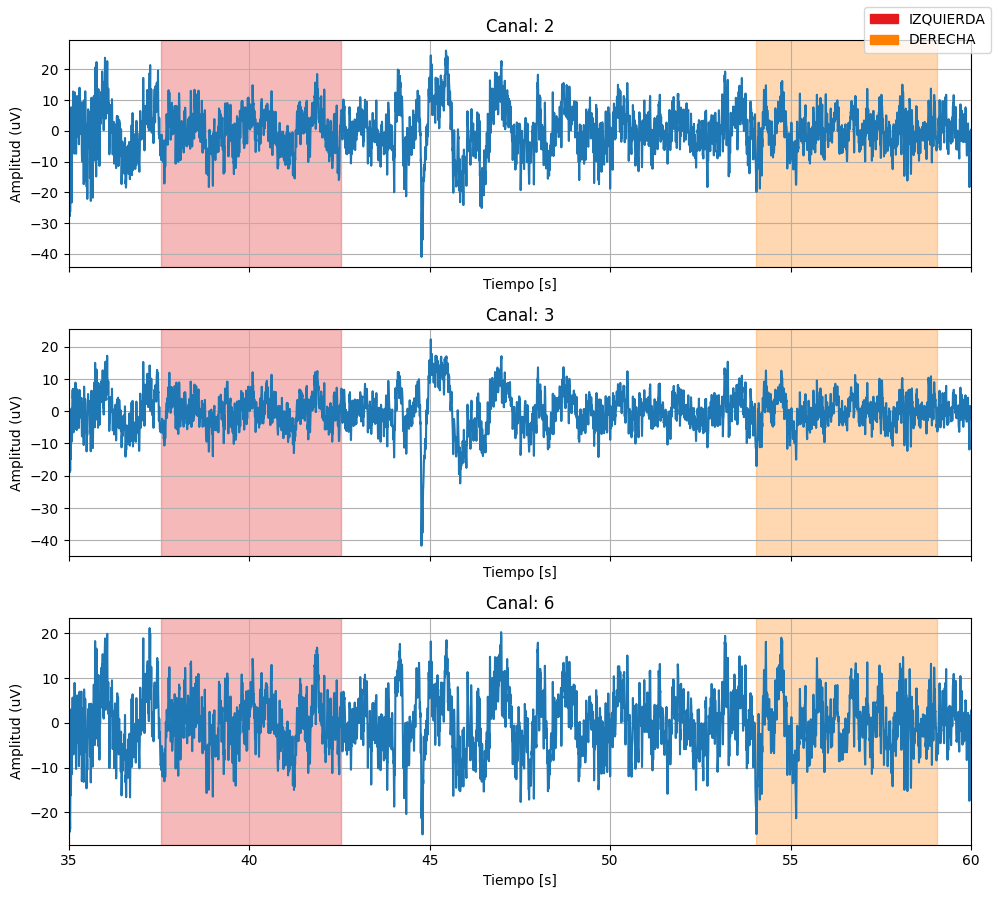

In [32]:
# Gráficamos nuestra señal recortada
recorte_señal.plot(picks=["2","3", "6"], show_anotaciones=True)

In [33]:
# Filtramos la señal
filtrada = recorte_señal.filter(l_freq=20, h_freq=100)

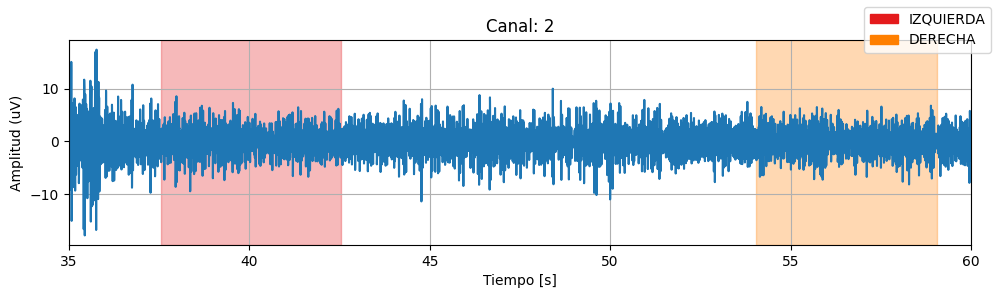

In [34]:
# Graficarmos la señal filtrada
filtrada.plot(picks=["2"])

In [52]:
class EEGSignal(RawSignal):
    """
    Clase para representar y analizar una señal de Electroencefalografía (EEG).

    Proporciona herramientas básicas para manipular y visualizar señales EEG, aplica filtrado espacial,
    y realiza análisis espectrales y temporales.

    """

    def __init__(self, data: np.ndarray, sfreq: float, info: Info = None, anotaciones: Anotaciones = None, first_samp: int = 0,
                referencia: str = "promedio", canal: str = None):
        """

        Extiende la clase base RawSignal e incorpora herramientas específicas para el análisis EEG,

        Args:
            data : Matriz 2D con forma (n_canales, n_muestras) que contiene la señal EEG cruda.

            sfreq : Frecuencia de muestreo de la señal (en Hz).

            info : Objeto con datos de la señal, como nombres de canales, tipo de canales, frecuencia de muestreo,
                   y otros datos del sujeto o experimento.

            anotaciones : Objeto que almacena las anotaciones temporales asociadas a eventos.

            first_samp : Índice del primer punto de la señal. Por defecto es 0.

            referencia : Tipo de referencia a aplicar a la señal EEG. Puede ser 'canal', 'promedio' o 'laplaciano'.
                         Por defecto se utiliza 'promedio'.

            canal : Nombre del canal de referencia si se elige referencia tipo 'canal'.

        Atributos:
            self.data_ref : Señal EEG con la referencia aplicada (se asigna desde set_reference()).

            self.referencia : Tipo de referencia actualmente aplicada.

        Raises:
            ValueError : Si el tipo de referencia especificado no es válido.

        """
        super().__init__(data, sfreq, info, anotaciones, first_samp)

        self.referencia = referencia
        self.canal_ref = canal
        self.set_reference(reference=referencia, channel=canal)

    def set_reference(self, reference: str, channel: str|int = None):
        """
        Cambia la referencia de la señal EEG. Opciones disponibles: 'canal', 'promedio' , 'laplaciano'.".

        """

        self.referencia = reference

        if self.referencia == "canal":
            self.data_ref = self._aplicar_referencia_a_canal(channel=channel)
        
        elif self.referencia == "promedio":
            self.data_ref = self._aplicar_referencia_promedio()

        elif self.referencia == "laplaciano":
            self._aplicar_referencia_laplaciana()

        else:
            raise ValueError("Tipo de referencia no reconocida. Debe usar 'canal', 'promedio' o 'laplaciano'.")
        
        return self.data_ref

    def _aplicar_referencia_a_canal(self, channel: str|int):
        """
        Cambia la referencia de todos los canales a un canal específico.

        Este método resta, muestra a muestra, la señal de un canal de referencia seleccionado al resto de los canales EEG. 

        """

        canales_disponibles = self.info.get("Nombre canales")

        if channel in canales_disponibles:
            channel_values = self.get_data([channel])
            reference = self.data - channel_values

        else:
            raise ValueError (f"El canal {channel} no existe. Canales disponibles: {canales_disponibles}")
        
        return reference

    def _aplicar_referencia_promedio(self):
        """
        Aplica una referencia promedio a la señal EEG.

        Este método calcula el promedio de todos los canales en cada muestra de tiempo
        y lo resta a cada canal individual, generando así una señal referenciada al promedio.
        """

        channel_values = self.get_data() 
        mean_reference = np.mean(channel_values, axis=0)
        reference = self.data - mean_reference
        return reference

    def _aplicar_referencia_laplaciana(self):
        """
        Aplica un filtro espacial Laplaciano para resaltar la actividad local de cada canal.

        Return:
            Señal con el filtro aplicado a todos los canales.
        """

        neighbors = self.info.get("Vecinos")
        canales = self.info.get("Nombre canales")

        if neighbors is None:
            raise ValueError("Faltan los campos 'Vecinos' en el objeto Info.")

        laplacian_data = np.zeros_like(self.data)

        for i, canal in enumerate(canales):
            vecinos = neighbors.get(canal, [])
            
            if not vecinos:
                laplacian_data[i, :] = self.data[i, :]               # Si no tiene vecinos, lo deja igual
                continue

            indices_vecinos = [canales.index(v) for v in vecinos]

            promedio = np.mean(self.data[indices_vecinos, :], axis=0)
            laplacian_data[i, :] = self.data[i, :] - promedio

        self.data_ref = laplacian_data
        return self.data_ref

    def espectro_frecuencias(self, picks : list, plot : bool = False, fmin : float = None, fmax :float = None):
        """
        Calcula el espectro de potencia de uno o más canales.

        Args:
            picks : Lista de canales a calcular la FFT. Si es None se calcula la de todos los canales
            plot : 
                - True : Muestra el gráfico del espectro de frecuencias
                - False : Por defecto, no muestra el gráfico
            fmin : Si se decide mostrar el gráfico, define desde que frecuencia mostrarlo (eje x del gráfico)
            fmax : Si se decide mostrar el gráfico, define hasta que frecuencia máxima mostrar (eje x del gráfico)
            
        Returns:
            frequencies : array de frecuencias (Hz)
            spectrum : array (n_canales, n_frecuencias)
        """

        n_canales, n_muestras = self.data_ref.shape

        if picks is None:                                    # Si picks queda por defecto, seleccionar todos los canales
            canales_idx = np.arange(n_canales)
        
        else:
            channels = self.info.get("Nombre canales")
            try:
                canales_idx = [channels.index(canal) for canal in picks]
            except:
                raise ValueError(f"Error: uno o más canales no se encuentran en los canales Ingresados desde el objeto Info")
        
        datos = self.data_ref[canales_idx]
        datos = np.atleast_2d(datos)                               # asegura que siempre sea 2D

        frequencies, spectrum = scipy.signal.welch(datos, fs=self.sfreq, nperseg=1024)
        spectrum = 10 * np.log10(spectrum)                         # dB re: 1 μV²/Hz

        fr_max_ejex = frequencies.max()                            # valor maximo de frecuencia
        fr_min_ejex = frequencies.min()

        if fmin:
            if isinstance (fmin, (int, float)):
                if fmin >= fr_min_ejex and fmin < fr_max_ejex:
                    fr_min_ejex = fmin
                else:
                    raise ValueError(f"La frecuencia mínima '{fmin}' debe estar entre {fr_min_ejex:.2f} y {fr_max_ejex:.2f} Hz.")
            else:
                raise ValueError (f"La frecuencia mínima ingresada ´{fmin}´ no es valida")
      
        if fmax:
            if isinstance (fmax, (int, float)):
                if fmax <= fr_max_ejex and fmax > fr_min_ejex:
                    fr_max_ejex = fmax
                else:
                    raise ValueError (f"La frecuencia máxima '{fmax}' debe ser mayor a la frecuencia minima establecida {fr_min_ejex:.2f} Hz.")
            else:
                raise ValueError (f"La frecuencia máxima ingresada '{fmax}' no es valida")

        if plot:
            self._plot_spectrum(frecuencias=frequencies, espectro=spectrum, indices=canales_idx, fmin=fr_min_ejex, fmax=fr_max_ejex)
    
        return frequencies, spectrum
    
    def fourier_spectrum(self, picks : list, plot : bool = False, fmin : float = None, fmax :float = None):
        """
        Calcula la FFT (transformada de Fourier) de uno o más canales.

        Args:
            picks : Lista de canales a calcular la FFT. Si es None se calcula la de todos los canales
            plot : 
                - True : Muestra el gráfico del espectro de frecuencias
                - False : Por defecto, no muestra el gráfico
            fmin : Si se decide mostrar el gráfico, define desde que frecuencia mostrarlo (eje x del gráfico)
            fmax : Si se decide mostrar el gráfico, define hasta que frecuencia máxima mostrar (eje x del gráfico)
            
        Returns:
            freqs : array de frecuencias (Hz)
            espectro : array (n_canales, n_frecuencias)
        """

        n_canales, n_muestras = self.data_ref.shape

        if picks is None:                                    # Si picks queda por defecto, seleccionar todos los canales
            canales_idx = np.arange(n_canales)
        
        else:
            channels = self.info.get("Nombre canales")
            try:
                canales_idx = [channels.index(canal) for canal in picks]
            except:
                raise ValueError(f"Error: uno o más canales no se encuentran en los canales Ingresados desde el objeto Info")
        
        datos = self.data_ref[canales_idx]
        datos = np.atleast_2d(datos)                         # asegura que siempre sea 2D

        fft_data = np.fft.rfft(datos, axis=1)                # calcula la Transformada Rápida de Fourier (FFT) real para cada canal (por filas).
        freqs = np.fft.rfftfreq(n_muestras, d=1/self.sfreq)  # calcula el vector de frecuencias correspondientes a la FFT.
        espectro = np.abs(fft_data)

        fr_max_ejex = freqs.max()                            # valor maximo de frecuencia
        fr_min_ejex = freqs.min()

        espectro = 10 * np.log10(espectro)       # dB re: 1 μV²/Hz

        if fmin:
            if isinstance (fmin, (int, float)):
                if fmin >= fr_min_ejex and fmin < fr_max_ejex:
                    fr_min_ejex = fmin
                else:
                    raise ValueError(f"La frecuencia mínima '{fmin}' debe estar entre {fr_min_ejex:.2f} y {fr_max_ejex:.2f} Hz.")
            else:
                raise ValueError (f"La frecuencia mínima ingresada '{fmin}' no es valida")
      
        if fmax:
            if isinstance (fmax, (int, float)):
                if fmax <= fr_max_ejex and fmax > fr_min_ejex:
                    fr_max_ejex = fmax
                else:
                    raise ValueError (f"La frecuencia máxima '{fmax}' debe ser mayor a la frecuencia minima establecida {fr_min_ejex:.2f} Hz.")
            else:
                raise ValueError (f"La frecuencia máxima ingresada '{fmax}' no es valida")

        if plot:
            self._plot_spectrum(frecuencias=freqs, espectro=espectro, indices=canales_idx, fmin=fr_min_ejex, fmax=fr_max_ejex)
    
        return freqs, espectro
    
    def _plot_spectrum(self, frecuencias:np.ndarray, espectro:np.ndarray, indices, fmin, fmax):
        """
        Genera un gráfico individual del espectro de Fourier para cada canal especificado.

        Args:
            frecuencias : Array unidimensional con las frecuencias correspondientes a los valores del espectro (en Hz).
            espectro : Matriz 2D de amplitudes espectrales con forma (n_canales, n_frecuencias), resultado de la transformada de Fourier.
            indices : Lista de índices de los canales que fueron seleccionados para análisis.
            fmin : Frecuencia mínima a mostrar.
            fmax : Frecuencia máxima a mostrar.

        """

        canales = self.info.get("Nombre canales")

        mask = (frecuencias >= fmin) & (frecuencias <= fmax)

        for i, idx in enumerate(indices):
            plt.figure(figsize=(8, 4))
            plt.plot(frecuencias[mask], espectro[i][mask], color='royalblue')
            plt.title(f"Espectro de Fourier - Canal {canales[idx]}")
            plt.xlabel("Frecuencia (Hz)")
            plt.ylabel("Amplitud")
            plt.grid(True)
            plt.tight_layout()
            plt.show()
    
    def plot_time_frequency(self, canal: str|int = 0, fmin=None, fmax=None, start_time=None, end_time=None, nperseg=256, absoluto=False):
        """
        Calcula y grafica una representación tiempo-frecuencia para un canal específico de EEG.

        Args:
            canal : índice o nombre del canal.
            fmin, fmax : límites del eje de frecuencia (Hz).
            start_time : Tiempo (en segundos) de inicio del gráfico
            end_time : Tiempo (en segundos) final del gráfico
            nperseg : tamaño de ventana para la STFT.
            absoluto : Ajusta el eje temporal de grafico (recomendado cuando se intenta usar el metodo en una señal previamente recortada)

        """
        
        if canal is None:
            canal_idx = 0

        elif isinstance(canal, int):
            canal_idx = canal

        elif isinstance(canal, str):
            if self.info is None or "Nombre canales" not in self.info:
                raise ValueError("No se puede identificar el canal por nombre: falta el objeto Info.")
            try:
                canal_idx = self.info["Nombre canales"].index(canal)
            except ValueError:
                raise ValueError(f"Canal '{canal}' no encontrado en Info.")
        else:
            raise ValueError("El parámetro 'canal' debe ser int, str o None.")
        
        if canal_idx < 0 or canal_idx >= self.data.shape[0]:
            raise ValueError("Índice de canal fuera de rango.")
        
        if absoluto:   # Restar el desplazamiento del segmento (usar solo para cuando tengo una señal ya recortada)
            if start_time is not None:
                start_time = start_time - self.first_samp
            if end_time is not None:
                end_time = end_time - self.first_samp
        
        start_idx = int(start_time * self.sfreq) if start_time is not None else 0
        end_idx = int(end_time * self.sfreq) if end_time is not None else self.data.shape[1]
        
        señal = self.data_ref[canal_idx, start_idx:end_idx].flatten()

        f, t, Sxx = spectrogram(señal, fs=self.sfreq, nperseg=nperseg)
        t_real = t + self.first_samp + (start_time if start_time is not None else 0)

        if fmin is not None: 
            f_mask = f >= fmin
            f = f[f_mask]
            Sxx = Sxx[f_mask, :]

        if fmax is not None: 
            f_mask = f <= fmax
            f = f[f_mask]
            Sxx = Sxx[f_mask, :]

        plt.figure(figsize=(10, 5))
        # plt.pcolormesh(t_real, f, Sxx, shading='gouraud', cmap='magma')
        plt.pcolormesh(t_real, f, 10 * np.log10(Sxx), shading='gouraud', cmap='magma')
        plt.title(f"EEG Tiempo-Frecuencia - Canal {canal}")
        plt.ylabel('Frecuencia [Hz]')
        plt.xlabel('Tiempo [s]')
        plt.colorbar(label='Potencia')
        plt.tight_layout()
        plt.show()

    def plot_hilbert_transform(self, picks=None, tmin:int|float=None, tmax:int|float=None):
        """
        Calcula y grafica la transformada de Hilbert de uno o varios canales, mostrando la envolvente.

        Args:
            picks : Lista de nombres de canales o None para gráficar todos los canales.
            tmin, tmax : Tiempo de inicio y fin del segmento a graficar (en segundos).

        Returns:
            hilbert_transform : Matriz compleja con la transformada de Hilbert aplicada.
        """
        if self.info is None or "Nombre canales" not in self.info:
            raise ValueError("Se requiere el objeto Info con los nombres de los canales para graficar la transformada de Hilbert.")
        
        channels = self.info.get("Nombre canales")         # Falta verificar si el objeto Info existe

        n_canales, n_muestras = self.data_ref.shape

        if picks is None:
            canales_idx = np.arange(n_canales)
        else:
            try:
                canales_idx = [channels.index(canal) for canal in picks]
            except:
                raise ValueError("Error: uno o más canales no se encuentran en el objeto Info.")

        start = 0
        end = n_muestras

        if tmin is not None:
            start = int(tmin * self.sfreq)

        if tmax is not None:
            end = int(tmax * self.sfreq)

        if start < 0 or end > n_muestras or start >= end:
            raise ValueError("Rango temporal inválido.")

        data_segment = self.data_ref[canales_idx, start:end]    # Recorto de señal

        hilbert_transform = scipy.signal.hilbert(data_segment)  # Aplico transformada de Hilbert
        envolvente = np.abs(hilbert_transform)

        tiempo = np.arange(start, end) / self.sfreq + self.first_samp           # Vector de tiempo

        for i, canal_idx in enumerate(canales_idx):
            plt.figure(figsize=(12, 4))
            plt.plot(tiempo, data_segment[i], label='Señal original')                       # Señal original
            plt.plot(tiempo, envolvente[i], linestyle='--', label='Envolvente (Hilbert)')   # Envolvente
            plt.title(f"Transformada de Hilbert - Canal: {channels[canal_idx]}")
            plt.xlabel("Tiempo (s)")
            plt.ylabel("Amplitud (uV)")
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        return hilbert_transform
    
    def filter(self, l_freq, h_freq, notch_freq = 50, order = 4):
        """
        Sobreescribe el metodo filter de RawSignal para que devuelva un objeto EEGSignal

        Aplica un filtro pasabanda (Butterworth) y un filtro notch a la señal fisiológica.
        El filtro notch permite eliminar una frecuencia fija (por defecto 50 Hz).
        Filtro pasabanda Butterworth que permite mantener solo las frecuencias entre l_freq y h_freq.

        Args:
            l_freq : Frecuencia de corte baja del filtro pasabanda (en Hz).
            h_freq : Frecuencia de corte alta del filtro pasabanda (en Hz).
            notch_freq : Frecuencia del filtro notch para eliminar ruido (por defecto 50 Hz).
            order : Orden del filtro Butterworth (por defecto 4).

        Returns:
            RawSignal : Nueva instancia de RawSignal con los datos filtrados.

        Raises:
            ValueError : Si las frecuencias de corte no son válidas.
        """

        filtrada = super().filter(l_freq, h_freq, notch_freq, order)
        
        return EEGSignal(filtrada.data, sfreq=self.sfreq, info=filtrada.info, anotaciones=filtrada.anotaciones, first_samp=filtrada.first_samp,
                         referencia=self.referencia, canal=self.canal_ref)
    
    def crop(self, tmin:int|float=0.0, tmax:int|float=None) -> "EEGSignal":
        """
        Sobreescribe el metodo crop de RawSignal para que devuelva un objeto EEGSignal

        Limita los datos dentro de EEGSignal para obtener un nuevo objeto EEGSignal pero con una cantidad de muestras recortadas.
        
        Args:
            tmin : Tiempo inicial en segundos para iniciar el recorte (por defecto es 0.0).
            tmax : Tiempo final en segundos para finalizar el recorte (por defecto es None).
        
        Return:
            EEGSignal : Nueva instancia de 'EEGSignal' que contiene el segmento temporal recortado.
        
        Raises
            Value Error : Si los tiempos 'tmin' o 'tmax' están fuera del rango de la señal. 
        
        """

        recorte = super().crop(tmin=tmin, tmax=tmax)
        
        return EEGSignal(recorte.data, sfreq=self.sfreq, info=recorte.info, anotaciones=recorte.anotaciones, first_samp=recorte.first_samp,
                         referencia=self.referencia, canal=self.canal_ref)
    
    def drop_channels(self, ch_names:list|np.ndarray) -> "EEGSignal":
        """ 
        Sobreescribe el metodo drop_channels de RawSignal para que devuelva un objeto EEGSignal

        Elimina uno o más canales a partir de ch_names.

        Args:
            ch_names : Nombres de canales a eliminar

        Return:
            Objeto EEGSignal """
        
        drop = super().drop_channels(ch_names=ch_names)
        return EEGSignal(drop.data, sfreq=self.sfreq, info=drop.info, anotaciones=drop.anotaciones, first_samp=drop.first_samp,
                         referencia=self.referencia, canal=self.canal_ref)
    
    def pick(self, canales=None, slice:list=None) -> "EEGSignal":
        """
        Sobreescribe el metodo pick de RawSignal para que devuelva un objeto EEGSignal

        Retorna un subset de canales seleccionados.

        Args:
            canales : Lista con los canales para armar el subset. Por defecto es None.
                Puede ser:
                    - list[str] : lista de nombres de canales
                    - list[int] : lista de índices de canales
            
            slice : Lista con los extremos para hacer slicing. Por defecto es None.
            
        Returns:
            EEGSignal : Nueva instancia con los canales seleccionados.

        Raises: ValueError:
                    Si el canal especificado no existe.
                    Si el índice está fuera del rango de canales. """
        
        picks = super().pick(canales=canales, slice=slice)
        return EEGSignal(picks.data, sfreq=self.sfreq, info=picks.info, anotaciones=picks.anotaciones, first_samp=picks.first_samp,
                         referencia=self.referencia, canal=self.canal_ref)

In [53]:
import json

with open("../2. Datos Prueba/eeg/eeg_vecinos.json", "r") as f:
    vecinos = json.load(f)

canales = range(1,63)
nombre_canales = []
for canal in canales:
    nombre_canales.append(str(canal))
    
tipos_canales = ["eeg"] * len(nombre_canales)
sujeto = {"Nombre": "Juan Acosta",
          "Edad": 26}

# Generamos el objeto Info

info_eeg = Info(experimenter= "Juan", subject_info=sujeto, ch_names=nombre_canales, ch_types=tipos_canales,
                bads=None, description= "Prueba", fm= 512, neighbors=vecinos )

anotaciones_file = Anotaciones(file="../2. Datos Prueba/eeg/eventos_ejemplo.csv")

eeg_data = np.load("../2. Datos Prueba/eeg/eeg_signal.npy")

In [54]:
# Instanciar clase EEG

eeg = EEGSignal(data=eeg_data, sfreq=512, info=info_eeg, anotaciones=anotaciones_file, first_samp=0, referencia="canal", canal="1")

In [55]:
eeg.data_ref[0]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

In [56]:
# Le cambio la referencia a un canal
ref = eeg.set_reference(reference="canal", channel="2")
ref.shape
ref[0]

array([   0.5746753,   12.765118 ,   93.63699  , ..., -131.17667  ,
       -139.6159   , -151.46333  ], dtype=float32)

In [57]:
ref_laplaciana = eeg.set_reference("laplaciano")
ref_laplaciana[0]

array([   0.3132112,    5.108612 ,   33.645447 , ..., -134.44702  ,
       -142.15036  , -153.25374  ], dtype=float32)

In [58]:
ref_promedio = eeg.set_reference(reference="promedio")
ref_promedio.shape
ref_promedio[0]

array([   1.493839,   26.415298,  181.00632 , ..., -131.14218 ,
       -136.10907 , -145.36543 ], dtype=float32)

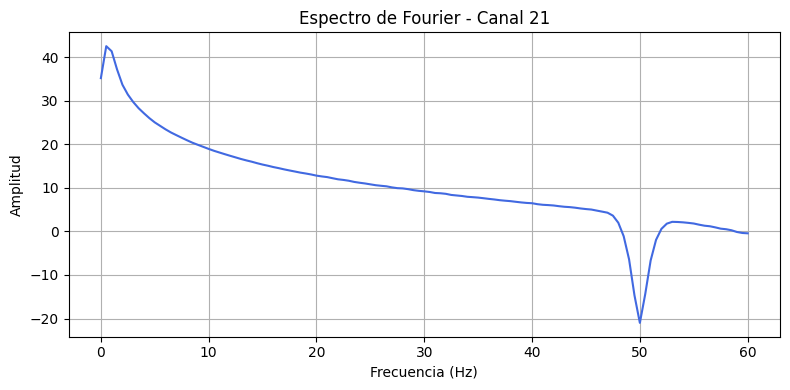

In [59]:
frec, espectro = eeg.espectro_frecuencias(picks=["21"],plot=True, fmin=0, fmax=60)

In [60]:
eeg_filtrada = eeg.filter(l_freq=0.1, h_freq=40)

In [61]:
eeg_filtrada_recortada = eeg_filtrada.crop(tmin=20, tmax=45)

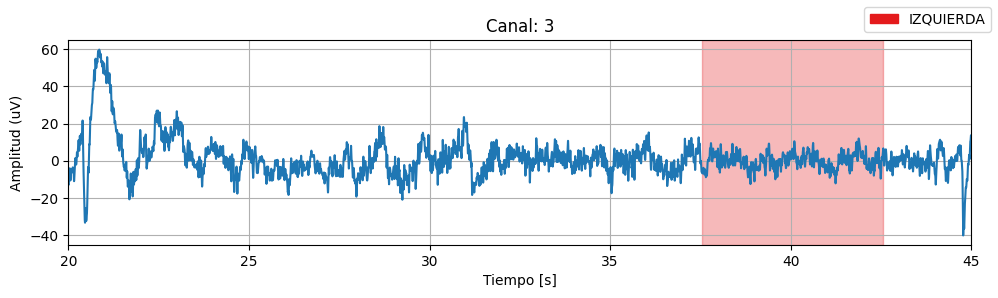

In [62]:
eeg_filtrada_recortada.plot(picks=["3"])

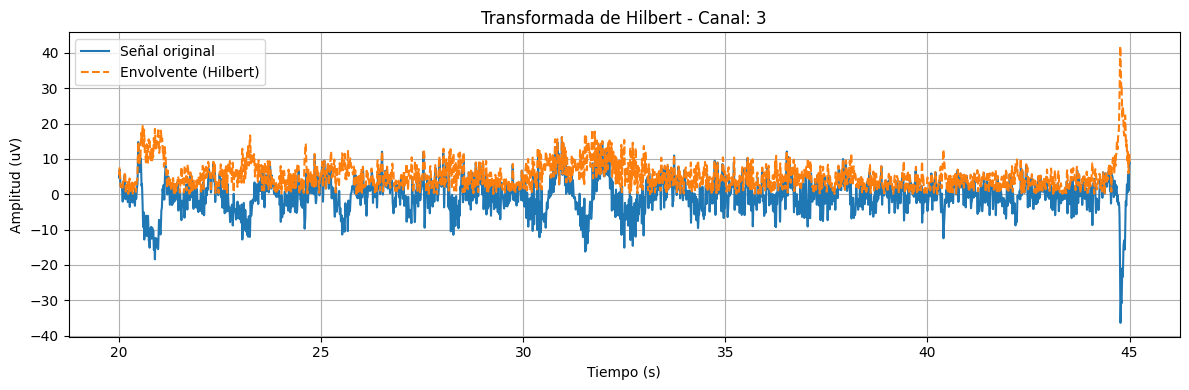

In [63]:
e = eeg_filtrada_recortada.plot_hilbert_transform(picks=["3"])

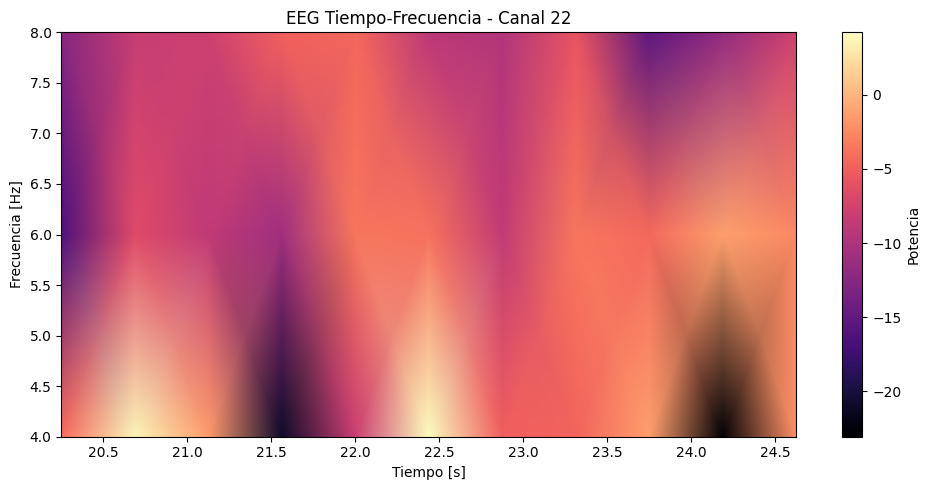

In [64]:
eeg_filtrada_recortada.plot_time_frequency(canal="22", fmin= 4,fmax=8, start_time=20, end_time=25, absoluto=True)